# ECG HR/HRV Pretraining — Fixed Version

Key fixes applied:
1. **Sliding-window extraction** — turns 22 records into thousands of training samples
2. **Correct `key_dim`** — set to `d_model // num_heads` (16) instead of 64
3. **Pre-LN Transformer** — more stable training
4. **Dropout** added for regularization on small dataset
5. **Cosine LR schedule** with warmup
6. **Proper evaluation** with train/val split

In [2]:
import os
import datetime
import numpy as np
import tensorflow as tf
import wfdb
import joblib

print("TF version:", tf.__version__)

I0000 00:00:1775488166.145818  216784 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775488166.228778  216784 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775488167.495536  216784 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0


In [6]:
import wfdb
import os

def download_afdb_records(max_records=30, cache_dir="../../db/afdb"):
    """
    Downloads and loads full 10-hour AFDB ECG signals.
    
    - Downloads the entire AFDB database ONCE into cache_dir
    - Loads full-length signals (≈10 hours, ~9.2M samples)
    - Skips broken records gracefully
    """
    os.makedirs(cache_dir, exist_ok=True)
    print(f"Using cache directory: {cache_dir}")
    print(os.path.exists(cache_dir))
    db_name = "afdb"

    records = wfdb.get_record_list(db_name)
    print(f"Found {len(records)} records in AFDB.")
    records = records[:max_records]

    # Download database once if missing
    if not any(fname.endswith(".hea") for fname in os.listdir(cache_dir)):
        print("Downloading AFDB database (one-time)...")
        wfdb.dl_database(db_name, dl_dir=cache_dir)
        print("Download complete. Using local cache.")

    signals = []

    for rec in records:
        try:
            print(f"\n=== Loading full record {rec} ===")
            record = wfdb.rdrecord(cache_dir + "/" + rec)

            sig = record.p_signal[:, 0].astype("float32")
            print(f"Loaded {sig.shape[0]} samples ({sig.shape[0] / 250 / 3600:.2f} hours)")

            signals.append(sig)

        except Exception as e:
            print(f"Skipping {rec}: {e}")
            continue

    return signals


# Example usage:
raw_signals = download_afdb_records(max_records=30)
print("\nDownloaded", len(raw_signals), "full-length ECG signals")

import joblib
joblib.dump(raw_signals, "../../db/afdb_signals.pkl")


Using cache directory: ../../db/afdb
True
Found 25 records in AFDB.

=== Loading full record 00735 ===
Skipping 00735: sampto must be greater than sampfrom

=== Loading full record 03665 ===
Skipping 03665: sampto must be greater than sampfrom

=== Loading full record 04015 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04043 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04048 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04126 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04746 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04908 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04936 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05091 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05121 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05261 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 06426 ===
L

['../../db/afdb_signals.pkl']

In [3]:
import numpy as np
import joblib
from joblib import Parallel, delayed
from scipy.signal import butter, filtfilt, find_peaks
import tensorflow as tf

# ============================================================
# 1. FAST R-PEAK DETECTOR (Pan-Tompkins style, vectorized)
# ============================================================

def bandpass_filter(ecg, fs=250, low=5, high=15):
    b, a = butter(1, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, ecg)

def fast_rpeak_detector(ecg, fs=250):
    x = bandpass_filter(ecg, fs)
    x2 = x * x
    win = int(0.15 * fs)
    mwa = np.convolve(x2, np.ones(win)/win, mode='same')
    peaks, _ = find_peaks(mwa, distance=int(0.25 * fs))
    return peaks

# ============================================================
# 2. HR + HRV (RMSSD) EXTRACTION with configurable window/step
# ============================================================

def fast_hr_hrv_from_rpeaks(rpeaks, fs=250, window_sec=60, step_sec=60):
    """
    Extract HR and HRV (RMSSD) from R-peaks using a sliding window.
    step_sec < window_sec creates overlapping windows = more samples.
    """
    if len(rpeaks) < 3:
        return None, None

    rr_intervals = np.diff(rpeaks) / fs
    rr_intervals = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

    if len(rr_intervals) < 3:
        return None, None

    rr_times = rpeaks[1:len(rr_intervals)+1] / fs
    t_max = rr_times[-1]
    times = np.arange(0, t_max - window_sec + 1, step_sec)

    hr = np.full(len(times), np.nan, dtype="float32")
    hrv = np.full(len(times), np.nan, dtype="float32")

    for i, t0 in enumerate(times):
        t1 = t0 + window_sec
        mask = (rr_times >= t0) & (rr_times < t1)
        if np.sum(mask) < 3:
            continue
        rr_win = rr_intervals[mask]
        hr_val = 60.0 / np.mean(rr_win)
        if 30 <= hr_val <= 220:
            hr[i] = hr_val
        diff_rr = np.diff(rr_win)
        if len(diff_rr) > 0:
            hrv[i] = np.sqrt(np.mean(diff_rr**2))

    valid = ~np.isnan(hr)
    if np.sum(valid) < 10:
        return None, None

    return hr[valid], hrv[valid]

def extract_hr_hrv_fast(ecg, fs=250):
    rpeaks = fast_rpeak_detector(ecg, fs)
    return fast_hr_hrv_from_rpeaks(rpeaks, fs)

# ============================================================
# 3. SLIDING WINDOW: extract many fixed-length subsequences
#    from each record's HR/HRV time series.
#    This is the KEY fix — turns 22 records into many samples.
# ============================================================

T = 128           # sequence length (minutes) — shorter = more samples
STEP = 32         # step size between windows — smaller = more overlap = more samples

def extract_windows(hr_seq, hrv_seq, T=128, step=32):
    """Slice a HR/HRV time series into fixed-length windows."""
    windows_hr, windows_hrv = [], []
    n = len(hr_seq)
    for start in range(0, n - T + 1, step):
        windows_hr.append(hr_seq[start:start+T])
        windows_hrv.append(hrv_seq[start:start+T])
    return windows_hr, windows_hrv

# ============================================================
# 4. LOAD & PROCESS
# ============================================================

raw_signals = joblib.load("../../db/afdb_signals.pkl")
print("Loaded raw signals:", len(raw_signals))

# Extract HR/HRV per record (in parallel)
results = Parallel(n_jobs=-1)(
    delayed(extract_hr_hrv_fast)(sig) for sig in raw_signals
)

# Slice into windows
hr_list, hrv_list = [], []
for hr, hrv in results:
    if hr is None:
        continue
    wins_hr, wins_hrv = extract_windows(hr, hrv, T=T, step=STEP)
    hr_list.extend(wins_hr)
    hrv_list.extend(wins_hrv)

hr_arr  = np.array(hr_list,  dtype="float32")   # (N, T)
hrv_arr = np.array(hrv_list, dtype="float32")   # (N, T)

# Activity is still zeros (placeholder for future wearable data)
activity_arr = np.zeros((hr_arr.shape[0], hr_arr.shape[1], 3), dtype="float32")

print(f"Total windows: {hr_arr.shape[0]}  (seq_len={T})")

# ============================================================
# 5. IMPUTE NaNs
# ============================================================

def impute_nan(arr):
    m = np.nanmean(arr, axis=1, keepdims=True)
    return np.where(np.isnan(arr), m, arr)

hr_arr  = impute_nan(hr_arr)
hrv_arr = impute_nan(hrv_arr)

print("HR shape:", hr_arr.shape, "  HRV shape:", hrv_arr.shape)
print(f"HR  range: [{hr_arr.min():.1f}, {hr_arr.max():.1f}]  mean={hr_arr.mean():.1f}")
print(f"HRV range: [{hrv_arr.min():.4f}, {hrv_arr.max():.4f}]  mean={hrv_arr.mean():.4f}")

Loaded raw signals: 23
Total windows: 177  (seq_len=128)
HR shape: (177, 128)   HRV shape: (177, 128)
HR  range: [105.6, 195.5]  mean=150.7
HRV range: [0.0033, 0.2253]  mean=0.1023


In [4]:
# ============================================================
# 6. TRAIN / VAL SPLIT
# ============================================================

N = hr_arr.shape[0]
idx = np.random.permutation(N)
split = int(0.85 * N)
train_idx, val_idx = idx[:split], idx[split:]

hr_train = hr_arr[train_idx]
hr_val   = hr_arr[val_idx]

print(f"Train: {hr_train.shape[0]}  |  Val: {hr_val.shape[0]}")

# ============================================================
# 7. TF DATASET WITH MASKING
# ============================================================
BATCH_SIZE = 32
MASK_RATIO = 0.15
SEQ_LEN = T  # 128

def make_ds(hr, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(hr)  # each element: (SEQ_LEN,)
    if shuffle:
        ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def add_mask(hr_batch, mask_ratio=MASK_RATIO):
    # hr_batch: (B, SEQ_LEN)
    mask = tf.cast(tf.random.uniform(tf.shape(hr_batch)) < mask_ratio, tf.float32)
    hr_masked = hr_batch * (1.0 - mask)
    return {
        "hr": hr_masked,    # input to model
        "target": hr_batch, # full target
        "mask": mask,       # for evaluation only
    }

def map_to_model_inputs(batch):
    inputs = {"hr": batch["hr"]}      # (B, SEQ_LEN)
    targets = batch["target"]         # (B, SEQ_LEN)
    return inputs, targets            # NO sample_weight here

train_ds = (
    make_ds(hr_train)
    .map(add_mask, num_parallel_calls=tf.data.AUTOTUNE)
    .map(map_to_model_inputs, num_parallel_calls=tf.data.AUTOTUNE)
)

val_ds = (
    make_ds(hr_val, shuffle=False)
    .map(add_mask, num_parallel_calls=tf.data.AUTOTUNE)
    .map(map_to_model_inputs, num_parallel_calls=tf.data.AUTOTUNE)
)




Train: 150  |  Val: 27


W0000 00:00:1775488180.836681  216784 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1775488180.842899  216784 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775488181.072186  216784 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9226 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [ ]:
# ============================================================
# 8. MODEL — Pre-LN Transformer with fixed key_dim
#
#  Fixes vs original:
#    * key_dim = d_model // num_heads  (was wrongly set to d_model)
#    * Pre-LN (LayerNorm BEFORE attention/FFN) — more stable
#    * Dropout added for regularisation
# ============================================================

def transformer_block_pre_ln(x, d_model, num_heads, dropout_rate=0.1):
    """Pre-LN Transformer block: LN → Attn → Add → LN → FFN → Add"""
    key_dim = d_model // num_heads   # FIX: was d_model (64) — now 16

    # Self-attention sub-layer
    x_ln = tf.keras.layers.LayerNormalization()(x)
    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate,
    )(x_ln, x_ln)
    attn = tf.keras.layers.Dropout(dropout_rate)(attn)
    x = tf.keras.layers.Add()([x, attn])

    # Feed-forward sub-layer
    x_ln = tf.keras.layers.LayerNormalization()(x)
    ff = tf.keras.layers.Dense(d_model * 4, activation="gelu")(x_ln)
    ff = tf.keras.layers.Dropout(dropout_rate)(ff)
    ff = tf.keras.layers.Dense(d_model)(ff)
    ff = tf.keras.layers.Dropout(dropout_rate)(ff)
    x = tf.keras.layers.Add()([x, ff])

    return x


def build_encoder(seq_len=128, d_model=64, num_heads=4, num_layers=3, dropout_rate=0.1):

    inputs = {
        "hr": tf.keras.Input(shape=(seq_len,), name="hr"),
    }

    hr = tf.keras.layers.Reshape((seq_len, 1))(inputs["hr"])
    hr = tf.keras.layers.Normalization(axis=-1, name="hr_norm")(hr)
    x = tf.keras.layers.Dense(d_model)(hr)

    pos = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=d_model)(pos)
    x = x + pos_emb

    for _ in range(num_layers):
        x = transformer_block_pre_ln(x, d_model, num_heads, dropout_rate)

    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.Dense(1)(x)
    x = tf.keras.layers.Reshape((seq_len,))(x)   # (B, SEQ_LEN)

    return tf.keras.Model(inputs=inputs, outputs=x, name="hr_encoder")

SEQ_LEN = T
encoder = build_encoder(seq_len=SEQ_LEN)

encoder.get_layer("hr_norm").adapt(hr_train.reshape(-1, SEQ_LEN, 1))
hr_input = tf.keras.Input(shape=(SEQ_LEN,), name="hr")
hr_out = encoder({"hr": hr_input})  # encoder expects dict
pretrain_model = tf.keras.Model(inputs={"hr": hr_input}, outputs=hr_out)

encoder.summary()


Model: "hr_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hr (InputLayer)     │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 1)    │          0 │ hr[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hr_norm             │ (None, 128, 1)    │          3 │ reshape[0][0]     │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 64)   │        128 │ hr_norm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 256)  │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │     16,448 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 64)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 64)   │          0 │ add_2[0][0],      │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 150,276 (587.02 KB)

 Trainable params: 150,273 (587.00 KB)

 Non-trainable params: 3 (16.00 B)

In [6]:
# ============================================================
# 9. TRAINING WITH COSINE LR SCHEDULE + EARLY STOPPING
# ============================================================



# Cosine decay with linear warmup
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, init_lr, warmup_steps, total_steps):
        super().__init__()
        self.init_lr       = init_lr
        self.warmup_steps  = tf.cast(warmup_steps,  tf.float32)
        self.total_steps   = tf.cast(total_steps,   tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.init_lr * (step / self.warmup_steps)
        cosine_lr = self.init_lr * 0.5 * (
            1.0 + tf.math.cos(
                np.pi * (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {"init_lr": self.init_lr,
                "warmup_steps": int(self.warmup_steps.numpy()),
                "total_steps":  int(self.total_steps.numpy())}

class R2Score(tf.keras.metrics.Metric):
    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.sst = self.add_weight(name="sst", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        self.sse.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sst.assign_add(tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true))))

    def result(self):
        return 1 - (self.sse / (self.sst + 1e-8))

    def reset_state(self):
        self.sse.assign(0.0)
        self.sst.assign(0.0)

EPOCHS      = 2000
STEPS_TRAIN = len(hr_train) // BATCH_SIZE

lr_schedule = WarmupCosineDecay(
    init_lr=3e-4,
    warmup_steps=5 * STEPS_TRAIN,
    total_steps=EPOCHS * STEPS_TRAIN,
)

pretrain_model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanAbsolutePercentageError(name="mape"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        R2Score(),
    ],
)

log_dir = os.path.join("logs", "pretrain", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"), "final")
callbacks = [
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
    ),
]

history = pretrain_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
)


Epoch 1/2000


I0000 00:00:1775488202.298999  217006 service.cc:153] XLA service 0x736d18051c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775488202.299025  217006 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.15.1)
I0000 00:00:1775488202.514739  217006 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775488203.499197  217006 cuda_dnn.cc:461] Loaded cuDNN version 91501
I0000 00:00:1775488203.801267  217006 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12425__.129
I0000 00:00:1775488206.166946  217213 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1775488207.561793  217217 subprocess_compilation.cc:348

1/5 ━━━━━━━━━━━━━━━━━━━━ 1:28 22s/step - loss: 150.3906 - mae: 150.8906 - mape: 100.3618 - r2: -179.7240 - rmse: 151.3317

I0000 00:00:1775488218.440856  217006 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 150.5223 - mae: 151.0223 - mape: 100.3836 - r2: -200.2092 - rmse: 151.4214 

I0000 00:00:1775488219.635567  217008 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12425__.129
I0000 00:00:1775488220.829347  217699 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_94', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775488220.877257  217707 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_94', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775488221.182671  217709 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775488223.166414  217698 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 4 bytes spill stores, 4 bytes spill loads



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 150.6222 - mae: 151.1222 - mape: 100.3693 - r2: -203.6965 - rmse: 151.5147  

I0000 00:00:1775488235.434749  217006 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13576__.32


5/5 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - loss: 150.7719 - mae: 151.2719 - mape: 100.3336 - r2: -203.4171 - rmse: 151.6644 - val_loss: 150.2096 - val_mae: 150.7096 - val_mape: 100.0370 - val_r2: -239.8611 - val_rmse: 151.0527
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 149.8401 - mae: 150.3401 - mape: 99.7046 - r2: -203.9198 - rmse: 150.7480 - val_loss: 148.0532 - val_mae: 148.5532 - val_mape: 98.5837 - val_r2: -233.1358 - val_rmse: 148.9289
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 147.8672 - mae: 148.3672 - mape: 98.3746 - r2: -197.4692 - rmse: 148.8085 - val_loss: 145.4578 - val_mae: 145.9578 - val_mape: 96.8473 - val_r2: -225.1193 - val_rmse: 146.3571
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 145.5655 - mae: 146.0655 - mape: 96.8357 - r2: -191.3476 - rmse: 146.5247 - val_loss: 143.1236 - val_mae: 143.6236 - val_mape: 95.2950 - val_r2: -217.9738 - val_rmse: 144.0261
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 143.4181 - ma

In [11]:
encoder.save("../../models/encoder_pretrained.h5")
print("Encoder saved to encoder_pretrained.h5")

np.savez(
    "../../db/hr_only_data_windows.npz",
    hr_arr=hr_arr,
)
print("Saved hr_only_data_windows.npz")

Encoder saved to encoder_pretrained.h5
Saved hr_only_data_windows.npz


I0000 00:00:1775488491.308504  217005 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_403975__.21


Validation MAE: 1.3940 BPM
(HR mean=150.7  std=10.5)


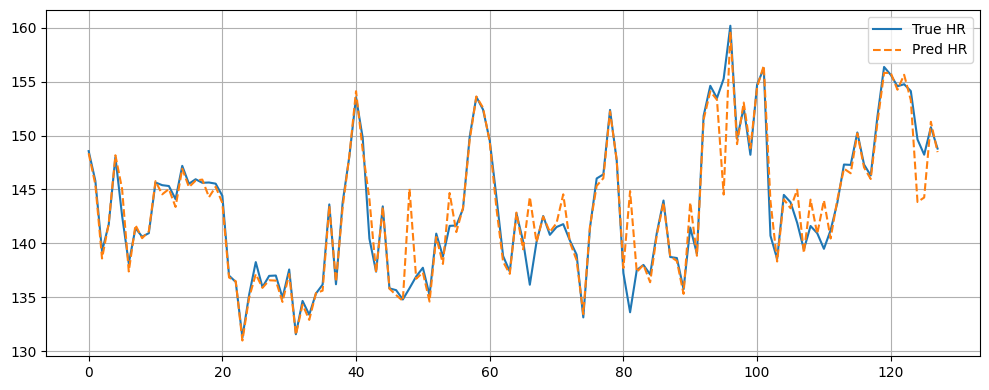

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

all_mae = []
for inputs, y_true in val_ds:
    y_pred = pretrain_model.predict(inputs, verbose=0)
    y_pred = tf.convert_to_tensor(y_pred)
    mae = tf.reduce_mean(tf.abs(y_pred - y_true))
    all_mae.append(mae.numpy())

print(f"Validation MAE: {np.mean(all_mae):.4f} BPM")
print(f"(HR mean={hr_arr.mean():.1f}  std={hr_arr.std():.1f})")

for inputs, y_true in val_ds.take(1):
    y_pred = pretrain_model.predict(inputs, verbose=0)[0]
    y_true_seq = y_true.numpy()[0]

t = np.arange(SEQ_LEN)
plt.figure(figsize=(10,4))
plt.plot(t, y_true_seq, label="True HR")
plt.plot(t, y_pred, "--", label="Pred HR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pretrain_results.png", dpi=120)
plt.show()

In [9]:
# Rebuild a val_ds_with_mask for eval
val_ds_with_mask = (
    make_ds(hr_val, shuffle=False)
    .map(add_mask, num_parallel_calls=tf.data.AUTOTUNE)
)

all_abs_errors = []

for batch in val_ds_with_mask:
    inputs = {"hr": batch["hr"]}
    y_true = batch["target"]          # (B, SEQ_LEN)
    mask   = batch["mask"]            # (B, SEQ_LEN)

    y_pred = pretrain_model.predict(inputs, verbose=0)
    y_pred = tf.convert_to_tensor(y_pred)

    abs_errors = tf.abs(y_pred - y_true) * mask
    all_abs_errors.append(abs_errors.numpy().flatten())

all_abs_errors = np.concatenate(all_abs_errors)
masked_errors = all_abs_errors[all_abs_errors > 0]

print(f"Masked MAE:    {masked_errors.mean():.3f} BPM")
print(f"Masked Median: {np.median(masked_errors):.3f} BPM")
print(f"Masked Std:    {masked_errors.std():.3f} BPM")
print(f"Masked 90th p: {np.percentile(masked_errors, 90):.3f} BPM")


Masked MAE:    5.408 BPM
Masked Median: 3.521 BPM
Masked Std:    5.872 BPM
Masked 90th p: 11.704 BPM
